# 📊 Social Media Engagement Prediction

## Project Overview
This project uses machine learning to analyze and predict social media post performance based on content characteristics, timing, and metadata.  
The goal is to understand what drives engagement and follower growth and to build predictive models that support content optimization.

## Project outline: 

* Problem Definition
* Data Preparation
* Exploratory Data Analysis
* Modeling
* Evaluation
* Interpretation & Insights

---


##  Dataset

**The dataset can be found here: https://www.kaggle.com/datasets/kundanbedmutha/instagram-analytics-dataset**

The dataset contains historical social media post data with the following feature groups:

- **Datetime:** upload time of the post  
- **Content metadata:** media type, content category, caption length, hashtag count  
- **Engagement metrics:** likes, comments, shares, saves, reach, impressions  
- **Growth metric:** followers gained  
- **Discovery:** traffic source


This dataset contains **30,000 Instagram posts** with detailed analytics generated to mimic **real Instagram Insights behavior** from the past **12 months**. It includes media performance indicators such as **likes, comments, shares, saves, reach, impressions, and engagement rate**.

The data reflects realistic patterns of **Instagram’s algorithm** and **content performance trends**, covering **Reels, Photos, Videos, and Carousels**.

All upload dates fall within the **previous 365 days**, making the dataset **time-relevant** and aligned with current Instagram usage behavior.


## Column Descriptions

| Column Name         | Description |
|--------------------|-------------|
| **Post_ID** | A unique identifier for each Instagram post. Useful as a primary key. |
| **Upload_Date** | The date the post was uploaded, within the last year. |
| **Media_Type** | Type of content: Photo, Video, Reel, or Carousel. Important for performance comparisons. |
| **Likes** | Number of likes received by the post. |
| **Comments** | Total number of comments on the post. |
| **Shares** | Number of times users shared the post. |
| **Saves** | Number of users who saved the content. A major Instagram ranking factor. |
| **Reach** | Number of unique accounts that saw the post. |
| **Impressions** | Total number of views from all sources (may exceed reach). |
| **Caption_Length** | Number of characters in the post caption. |
| **Hashtags_Count** | Total number of hashtags used in the post. |
| **Followers_Gained** | Number of followers gained directly from this post. |
| **Traffic_Source** | Where viewers discovered the post (Explore, Home Feed, Hashtags, Profile, Reels Feed, External). |
| **Engagement_Rate** | Percentage of engagement relative to impressions. Useful for performance scoring. |

---


This dataset enables analysis of:

- High-performing media types  
- Traffic sources that generate the most reach  
- Optimal hashtag usage  
- Relationship between caption length and engagement  
- Factors influencing follower growth  
- Predicting engagement rate trends  


---



## 1. Problem Definition
### Machine Learning Tasks
- **Regression**
  - Predict `followers_gained`
  - Predict `engagement_rate`

---



## 2. Data Preparation
- Data cleaning and type conversion  
- Feature engineering from upload timestamp  
- Encoding categorical variables  
- Preventing data leakage in engagement-related targets  

---


In [4]:
# Importing all tools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [7]:
df = pd.read_csv("data/Instagram_Analytics.csv", sep=";")
df.head()


,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,2024-11-30 09:25:22.954916,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,2025-08-15 09:25:22.954916,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,2025-09-11 09:25:22.954916,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,2025-09-18 09:25:22.954916,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,2025-03-21 09:25:22.954916,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   post_id           29999 non-null  object 
 1   upload_date       29999 non-null  object 
 2   media_type        29999 non-null  object 
 3   likes             29999 non-null  int64  
 4   comments          29999 non-null  int64  
 5   shares            29999 non-null  int64  
 6   saves             29999 non-null  int64  
 7   reach             29999 non-null  int64  
 8   impressions       29999 non-null  int64  
 9   caption_length    29999 non-null  int64  
 10  hashtags_count    29999 non-null  int64  
 11  followers_gained  29999 non-null  int64  
 12  traffic_source    29999 non-null  object 
 13  engagement_rate   29999 non-null  float64
 14  content_category  29999 non-null  object 
dtypes: float64(1), int64(9), object(5)
memory usage: 3.4+ MB


For further work some of the data formats have to be changed. 
* The "upload_date" will be changed to the datetime format for the time-based splits.
* media_type, traffic_source and content_category will be turned into the category format for time optimisation.
  



In [11]:
  
df["upload_date"] = pd.to_datetime(df["upload_date"])
df["media_type"] = df["media_type"].astype("category")
df["traffic_source"] = df["traffic_source"].astype("category")
df["content_category"] = df["content_category"].astype("category")


In [12]:
df.dtypes

post_id                     object
upload_date         datetime64[ns]
media_type                category
likes                        int64
comments                     int64
shares                       int64
saves                        int64
reach                        int64
impressions                  int64
caption_length               int64
hashtags_count               int64
followers_gained             int64
traffic_source            category
engagement_rate            float64
content_category          category
dtype: object

In [26]:
# Time-based features

df["day_of_week"] = df["upload_date"].dt.dayofweek  # 0=Monday
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df[["upload_date", "day_of_week", "is_weekend"]].head()




,upload_date,day_of_week,is_weekend
0,2024-11-30 09:25:22.954916,5,1
1,2025-08-15 09:25:22.954916,4,0
2,2025-09-11 09:25:22.954916,3,0
3,2025-09-18 09:25:22.954916,3,0
4,2025-03-21 09:25:22.954916,4,0



## 3. Exploratory Data Analysis
- Distribution of engagement metrics  
- Performance by media type and content category  
- Effect of posting time on engagement  

---


## Media type vs engagement & follower growth

First, we will analyse if the engagement and the number of followers change based on Media type.

In [17]:
# followers gained from each post type

df.groupby("media_type",  observed=True)["followers_gained"].mean().sort_values(ascending=False)

media_type
Photo       505.305582
Carousel    504.675525
Video       504.456201
Reel        494.201331
Name: followers_gained, dtype: float64

### Plot 1: Followers gained by media type

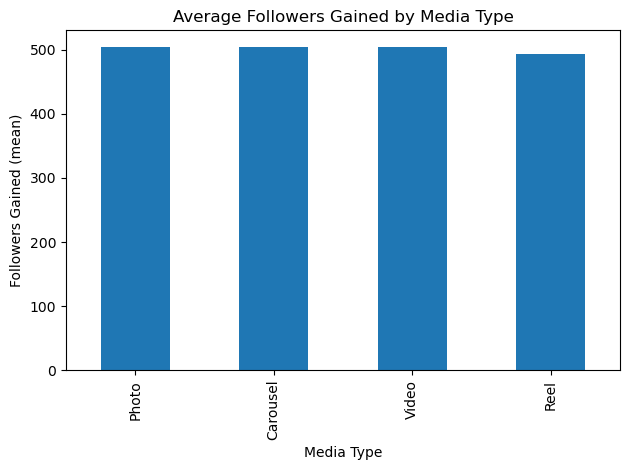

In [18]:
media_followers = (
    df.groupby("media_type",  observed=True )["followers_gained"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
media_followers.plot(kind="bar")
plt.title("Average Followers Gained by Media Type")
plt.xlabel("Media Type")
plt.ylabel("Followers Gained (mean)")
plt.tight_layout()
plt.show()


### Plot 2: Engagement rate by media type

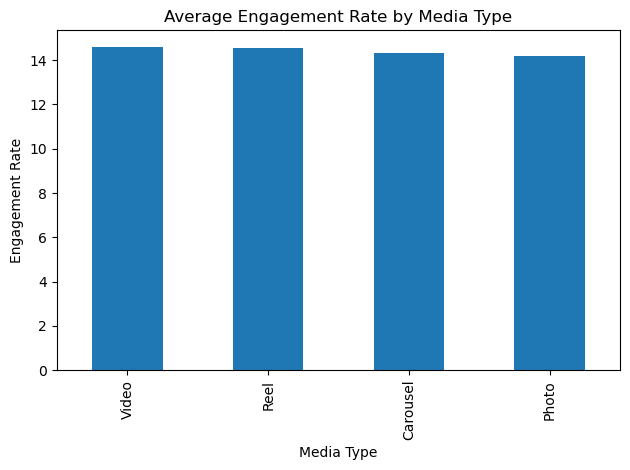

In [19]:
media_engagement = (
    df.groupby("media_type", observed=True )["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
media_engagement.plot(kind="bar")
plt.title("Average Engagement Rate by Media Type")
plt.xlabel("Media Type")
plt.ylabel("Engagement Rate")
plt.tight_layout()
plt.show()


*The average number of followers gained per post is relatively similar across different media types. Photos, carousels, and videos show almost identical performance, each resulting in approximately 504–505 followers gained on average. Reels perform slightly lower, with an average of about 494 followers gained per post. Overall, media type alone does not appear to be a strong differentiating factor for follower growth in this dataset, suggesting that other variables such as content category, timing, or distribution channel may play a more significant role. Media type doesn't seem to have a direct influence on the engagement rate either*

## Content category vs performance

### Plot: Followers gained by content category

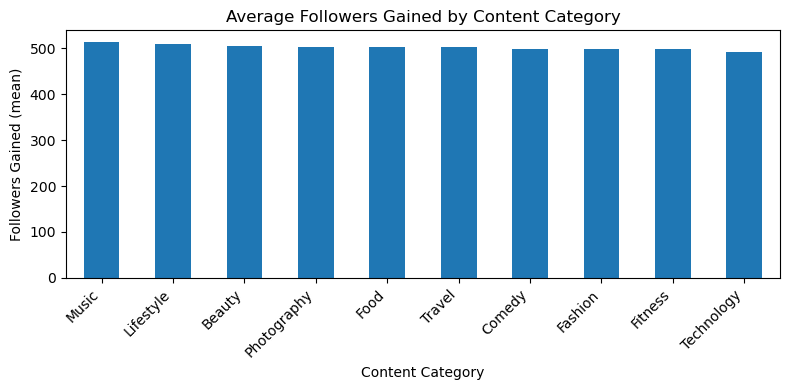

In [21]:
category_followers = (
    df.groupby("content_category",  observed=True )["followers_gained"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
category_followers.plot(kind="bar")
plt.title("Average Followers Gained by Content Category")
plt.xlabel("Content Category")
plt.ylabel("Followers Gained (mean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [22]:
# followers gained from each post type

df.groupby("content_category",  observed=True)["followers_gained"].mean().sort_values(ascending=False)

content_category
Music          512.873793
Lifestyle      508.992377
Beauty         505.479512
Photography    503.241516
Food           503.049502
Travel         503.033019
Comedy         498.470508
Fashion        497.576796
Fitness        497.250000
Technology     491.641983
Name: followers_gained, dtype: float64

### Posting time vs engagement

In [30]:
df["day_of_week"].value_counts().sort_index()


day_of_week
0    4279
1    4351
2    4341
3    4351
4    4218
5    4254
6    4205
Name: count, dtype: int64

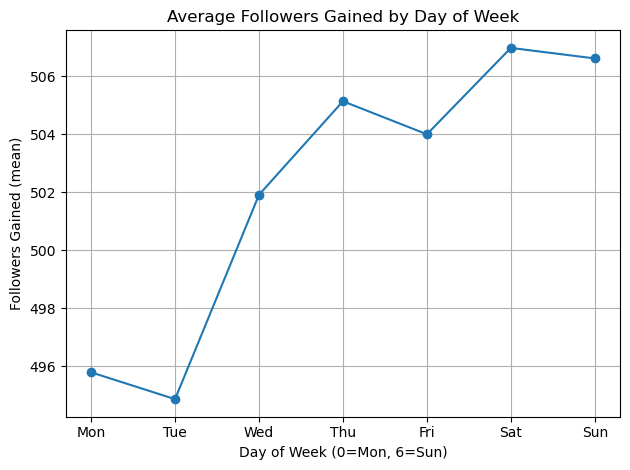

In [31]:
day_followers = (
    df.groupby("day_of_week", observed=True)["followers_gained"]
    .mean()
)

plt.figure()
plt.plot(day_followers.index, day_followers.values, marker="o")
plt.title("Average Followers Gained by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Followers Gained (mean)")
plt.xticks(range(0, 7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.grid(True)
plt.tight_layout()
plt.show()


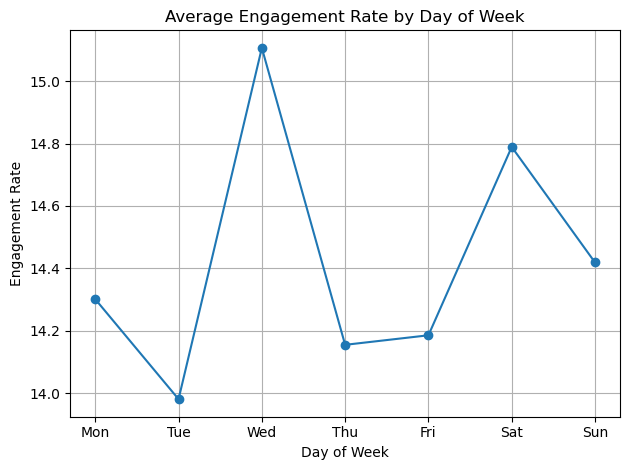

In [32]:
day_engagement = (
    df.groupby("day_of_week", observed=True)["engagement_rate"]
    .mean()
)

plt.figure()
plt.plot(day_engagement.index, day_engagement.values, marker="o")
plt.title("Average Engagement Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Engagement Rate")
plt.xticks(range(0, 7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.grid(True)
plt.tight_layout()
plt.show()


### Summary: Performance by Day of Week
*Follower growth shows moderate variation across the week. Posts published on weekends (Saturday and Sunday) achieve the highest average number of followers gained, while Monday and Tuesday show the lowest averages. From Wednesday onward, follower growth generally increases, peaking on Saturday, which suggests that audience responsiveness may be slightly higher toward the end of the week.
Engagement rate follows a somewhat different pattern. The highest average engagement is observed on Wednesday, with a secondary peak on Saturday. Tuesday shows the lowest engagement rate, while the remaining days are relatively close to one another. This indicates that days with higher engagement are not always the same days that drive the highest follower growth.
Overall, while day of the week does influence performance, the differences are relatively small. Posting day alone does not appear to be a dominant driver of either engagement or follower acquisition, but it provides useful contextual signal and may contribute modestly when combined with other factors such as content type, category, and traffic source.*


## 4. Modeling
- Baseline model: Linear Regression  
- Tree-based models: Random Forest, Gradient Boosting  
- Train–validation split and cross-validation  

Primary target: followers_gained
 
---


In [35]:
#Select relevant columns

df_model = df.drop(columns=["post_id", "upload_date", "hour"], errors="ignore")


In [36]:
df_model.head()

,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category,day_of_week,is_weekend
0,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology,5,1
1,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness,4,0
2,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty,3,0
3,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music,3,0
4,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology,4,0


In [80]:
features = [
    "media_type",
    "content_category",
    "traffic_source",
    "caption_length",
    "hashtags_count",
    "day_of_week",
    "is_weekend",
    "reach",
    "impressions",
    "comments",
    "shares",
    "saves",
]


target = "likes"





In [81]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



### Preprocessing pipeline

In [82]:
categorical_features = [
    "media_type",
    "content_category",
    "traffic_source",
]

numerical_features = [
    "caption_length",
    "hashtags_count",
    "day_of_week",
    "is_weekend",
    "reach",
    "impressions",
    "comments",
    "shares",
    "saves",
]


In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features),
    ]
)


### Baseline model (Linear Regression)

In [84]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression()),
    ]
)

baseline_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2


(50544.445872417906, np.float64(58165.636348618995), -0.0003506042751486582)

### Random Forest for Reach Feature

In [86]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )),
    ]
)

rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [87]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf


(50823.13419833333, np.float64(58571.71018636465), -0.014366927328900214)

In [88]:
# Interpret feature importance

feature_names = (
    rf_model.named_steps["preprocess"]
    .get_feature_names_out()
)

importances = rf_model.named_steps["model"].feature_importances_

fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

fi.head(10)


,feature,importance
28,num__saves,0.122357
26,num__comments,0.121711
27,num__shares,0.120366
20,num__caption_length,0.119127
24,num__reach,0.107091
25,num__impressions,0.106400
21,num__hashtags_count,0.080481
22,num__day_of_week,0.041582
3,cat__media_type_Video,0.010491
2,cat__media_type_Reel,0.010137


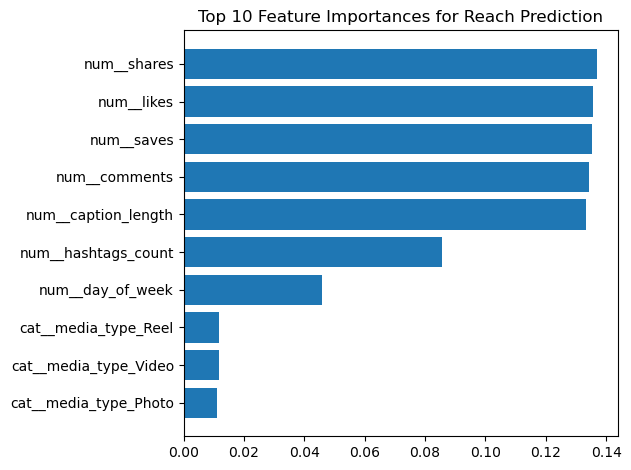

In [68]:
top_fi = fi.head(10)

plt.figure()
plt.barh(top_fi["feature"], top_fi["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances for Reach Prediction")
plt.tight_layout()
plt.show()


### Linear Regression baseline for target of followers_gained (proved to be not informative)

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression()),
    ]
)

baseline_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2


(250.37759868524856, np.float64(289.0262841512153), 0.0002766965337367422)

### Random Forest Model

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )),
    ]
)

rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [44]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf


(251.99925333333334, np.float64(292.131581180881), -0.021320749846971188)

#### *Target will be changed to reach of a post, to see if there is a better correlation in this direction.*

In [ ]:
target = "reach"



## 5. Evaluation
- Metrics: RMSE, MAE, R²  
- Model comparison and performance analysis  

---

### Modeling Results Summary

| Target | Result | Explanation |
|------|--------|-------------|
| `followers_gained` | ❌ Very poor | Follower growth is highly noisy and influenced by external factors not captured in the dataset |
| `reach` (with impressions) | ✅ Excellent | Impressions act as a near-proxy for reach, resulting in very high predictive performance |
| `reach` (without impressions) | ❌ Poor | Once impressions are removed, no meaningful signal remains to explain reach |
| `impressions` | ❌ Poor | Impressions are largely controlled by platform-level algorithms rather than post-level features |




## 6. Interpretation & Insights
- Feature importance analysis  
- Key drivers of engagement and follower growth  
- Practical content optimization insights  

---

## 📌 Summary of Findings

This project explored the extent to which social media post performance can be explained and predicted using post-level metadata, engagement signals, and timing information. The dataset contains approximately 30,000 posts with content attributes (media type, category, caption length, hashtags), timing features, engagement metrics, and exposure metrics.

---

### 1. Exploratory Data Analysis

Exploratory analysis revealed that most content-related features exhibit **only small average differences** across groups:

- **Media type** (Photo, Carousel, Video, Reel) shows minimal variation in follower growth and engagement, indicating that format alone is not a strong differentiator.
- **Posting day** has a mild effect: weekends tend to perform slightly better in terms of follower growth, while engagement peaks mid-week. However, these effects are relatively small.
- **Posting hour** could not be analyzed, as all posts were published at the same hour, making it non-informative.

Overall, EDA suggested that no single content or timing feature strongly drives performance on its own.

---

### 2. Predicting Follower Growth

Initial regression models attempted to predict `followers_gained`.

- Both Linear Regression and Random Forest models performed **no better than predicting the mean** (R² ≈ 0).
- This indicates that follower acquisition is highly noisy and likely influenced by external factors such as audience size, trends, and platform dynamics that are not present in the dataset.

**Conclusion:** Follower growth cannot be reliably predicted using post-level metadata and engagement signals alone.

---

### 3. Predicting Reach

Reach was evaluated as a potentially more stable target.

- When **impressions were included as a feature**, reach could be predicted with very high accuracy (R² ≈ 0.94).
- Feature importance analysis showed that impressions accounted for over 95% of the predictive power, revealing a near-proxy relationship between impressions and reach.
- When impressions were removed, model performance collapsed (R² ≈ 0), indicating that reach is primarily determined by distribution mechanisms rather than content attributes.

**Conclusion:** Reach is predictable only when using impressions, which limits the interpretability and usefulness of the model for content strategy.

---

### 4. Predicting Impressions

Models predicting `impressions` using content metadata and engagement actions performed poorly.

- Both linear and non-linear models achieved R² values close to zero.
- This suggests that impressions are largely controlled by platform-level algorithms and are not directly explainable by post-level features.

**Conclusion:** Impressions cannot be reliably predicted from the available data.

---

### 5. Predicting Likes

Regression models were also trained to predict `likes`.

- Both Linear Regression and Random Forest failed to outperform a mean baseline.
- This indicates that likes are driven by latent factors such as content quality, emotional resonance, novelty, and audience context, none of which are captured in the dataset.

**Conclusion:** User engagement actions such as likes are weakly related to the available features and are not suitable regression targets in this dataset.

---

### 6. Overall Conclusions

Across multiple modeling attempts, a consistent pattern emerged:

- Metrics tied to **algorithmic distribution** (impressions, reach) are not predictable from post-level metadata.
- Metrics tied to **user behavior** (likes, followers gained) are highly noisy and influenced by unobserved factors.
- Strong predictive performance is only achieved when using **near-proxy features**, which limits interpretability.

These findings highlight the importance of aligning machine learning objectives with the underlying data-generating process and demonstrate that not all performance metrics are equally suitable for prediction.

---

### 7. Key Takeaways

- Negative modeling results can be meaningful and informative.
- High model accuracy may indicate proxy leakage rather than true insight.
- Careful feature selection and target choice are critical in applied machine learning.
- Understanding *why* a model fails is often as valuable as building a successful one.
